In [1]:
%matplotlib inline

# SSVEP harmonics & the TRCA pipeline

This notebook is the **visual companion** to the NeuroPawn SSVEP tutorial. It
lets you *see* the ideas behind the BCI before you trust the numbers:

1. **How SSVEP produces harmonics** — why a flickering target creates peaks not
   just at its frequency `f`, but also at `2f`, `3f`, …
2. **Stimulus frequencies vs the filter bank** — how the TRCA filter bank is
   designed to scoop up those harmonics.
3. **Load your recorded data** — using the same loader the real-time system uses.
4. **See the SSVEP peak in real EEG** — spot the target frequency in a recorded trial.
5. **Run the TRCA pipeline** — leave-one-block-out cross-validation + a single-trial demo.

Everything reuses the reusable code in the [`ssvep/`](ssvep) package, so the
notebook and the live scripts stay perfectly in sync.

> Based on the TRCA method of Nakanishi et al. (2018) and the filter-bank idea of
> Chen et al. (2015), via [`meegkit.trca.TRCA`](https://github.com/nbara/python-meegkit).


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# The reusable pipeline (see the ssvep/ modules for the commented implementation).
from ssvep import config as cfg
from ssvep.trca_model import load_training_data, build_model, cross_validate

print("Stimulus frequencies (Hz):", cfg.STIMULUS_FREQUENCIES)
print("Sampling rate (Hz):      ", cfg.SAMPLING_RATE)
print("Analysis window (s):     ", cfg.GAZE_DURATION, "after", cfg.VISUAL_LATENCY, "s latency")


## 1. How SSVEP produces harmonics

When you stare at a target flashing at frequency `f`, your visual cortex
entrains to it — but the response is **not a clean sine wave**. The flicker is
closer to a square wave (fully on / fully off), and the cortex's response is a
distorted, periodic signal. Any periodic signal is a sum of a **fundamental**
(`f`) plus **harmonics** (`2f`, `3f`, …).

That is great news for a BCI: instead of relying on a single frequency peak,
we can pool evidence from `f`, `2f`, `3f`… which makes detection far more
robust. The cell below simulates this and shows the harmonic peaks in the
spectrum.


In [ ]:
# Simulate the cortical SSVEP response to one flickering target.
f0 = 10.0                       # target flicker frequency [Hz]
fs = 500                        # fine sampling, just for this illustration
t = np.arange(0, 2, 1 / fs)

# A realistic response = fundamental + decaying harmonics + a little noise.
response = sum((1.0 / k) * np.sin(2 * np.pi * k * f0 * t) for k in range(1, 4))
response += 0.10 * np.random.randn(t.size)

# Magnitude spectrum (single-sided).
spectrum = np.abs(np.fft.rfft(response)) / t.size
freqs = np.fft.rfftfreq(t.size, 1 / fs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(t[t < 0.5], response[t < 0.5], color="C0")
ax1.set(title=f"Time domain ({f0:.0f} Hz SSVEP response)",
        xlabel="Time (s)", ylabel="Amplitude")

ax2.plot(freqs, spectrum, color="C3")
for k in range(1, 4):
    ax2.axvline(k * f0, ls="--", color="gray")
    ax2.text(k * f0 + 0.5, spectrum.max() * 0.85, f"{k}×f0", color="gray")
ax2.set(title="Frequency domain: fundamental + harmonics",
        xlabel="Frequency (Hz)", ylabel="Magnitude", xlim=(0, 50))
plt.tight_layout()
plt.show()


[[ 6.67]
 [ 8.57]
 [10.  ]
 [12.  ]]


## 2. Stimulus frequencies vs the filter bank

The **filter bank** (`cfg.FILTERBANK`) splits the EEG into several overlapping
sub-bands before TRCA looks at it. Each sub-band is positioned to capture a
different harmonic range, so the classifier uses the fundamentals *and* the
harmonics of every target frequency.

The plot below shows each sub-band (coloured stripes: darker = pass-band,
lighter = stop-band) together with each stimulus frequency and its first nine
harmonics (dots). Notice how the harmonics of all four targets fall inside the
sub-bands — that is what the filter bank is designed to collect.


In [ ]:
# Filter-bank sub-bands (from cfg) plotted against the stimulus harmonics.
filterbank = cfg.FILTERBANK
list_freqs = np.array(cfg.STIMULUS_FREQUENCIES)

fig, ax = plt.subplots(1, figsize=(8, 4))
for i, band in enumerate(filterbank):
    (wp_lo, wp_hi), (ws_lo, ws_hi) = band
    y0, y1 = i / len(filterbank) + 0.02, (i + 1) / len(filterbank) - 0.02
    # stop-band (light) then pass-band (solid) as horizontal stripes
    ax.axvspan(ws_lo, ws_hi, ymin=y0, ymax=y1, alpha=0.2, facecolor=f"C{i}")
    ax.axvspan(wp_lo, wp_hi, ymin=y0, ymax=y1, alpha=0.5, facecolor=f"C{i}",
               label=f"sub-band {i}")

# Each stimulus frequency + its first 9 harmonics.
for f in list_freqs:
    shades = np.ones((9, 4))
    shades[:, :3] = np.linspace(0, 0.5, 9)[:, None]
    ax.scatter(f * np.arange(1, 10), [f] * 9, c=shades, s=10, zorder=100)

ax.set(xlabel="EEG response frequency (Hz)", ylabel="Stimulus frequency (Hz)",
       xlim=[0, 102], xticks=np.arange(0, 100, 10))
ax.grid(True, ls=":", axis="x")
ax.legend(bbox_to_anchor=(1.02, 0.5), fontsize="small")
plt.tight_layout()
plt.show()


(187, 8, 64)
[0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0
 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3]
(125, 8, 64)


## 3. Load your recorded data

We load blocks with the **same function the real-time system uses**
(`ssvep.trca_model.load_training_data`), so what you see here matches what the
classifier sees. Each block contains one trial per target; the loader crops
every trial to the 1 s analysis window (after the visual-latency delay) and
returns an `(samples, channels, trials)` cube, the per-trial labels, and the
sampling rate it recovered from the recorded files' length.

Point `DATA_DIR` at whichever folder holds your `block_{block}_{trial}.csv`
files.


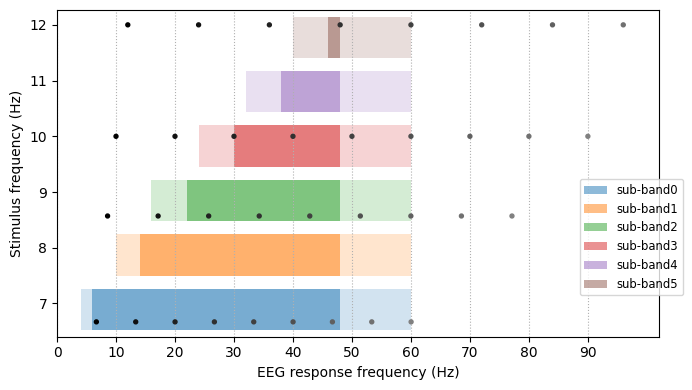

In [ ]:
# Change this to your data folder (defaults to the bundled example recordings).
DATA_DIR = os.path.join(cfg.PROJECT_ROOT, "datarecording")


def count_blocks(folder):
    """How many complete blocks exist (looks for block_{b}_1.csv)."""
    n = 0
    while os.path.exists(os.path.join(folder, f"block_{n + 1}_1.csv")):
        n += 1
    return n


n_blocks = count_blocks(DATA_DIR)
print(f"Found {n_blocks} block(s) in {DATA_DIR}")

eeg, labels, sampling_rate = load_training_data(DATA_DIR, n_blocks)
print("EEG cube (samples, channels, trials):", eeg.shape)
print("Labels (target index per trial):     ", labels)
print("Sampling rate recovered (Hz):        ", sampling_rate)


## 4. See the SSVEP peak in real EEG

Before trusting the classifier, look at the data with your own eyes. Pick a
recorded trial, average the spectrum across channels, and check that the
biggest peak sits at the frequency the user was actually staring at (and often
a smaller bump at the 2nd harmonic). If you *can't* see a peak here, no
classifier will save you — fix electrode contact / timing first.

> Note: the analysis window is only 1 s long, so the frequency resolution is
> ~1 Hz. The peak will land on the nearest bin to the target frequency.


In [ ]:
# Pick any trial and plot its channel-averaged magnitude spectrum.
trial_idx = 2                              # try different values (0 .. trials-1)
target = int(labels[trial_idx])
target_freq = cfg.STIMULUS_FREQUENCIES[target]

trial = eeg[:, :, trial_idx]               # (samples, channels)
n = trial.shape[0]
spec = np.abs(np.fft.rfft(trial, axis=0)).mean(axis=1) / n
fbins = np.fft.rfftfreq(n, 1 / sampling_rate)

plt.figure(figsize=(9, 3.5))
plt.plot(fbins, spec, color="C0")
plt.axvline(target_freq, ls="--", color="C3", label=f"target = {target_freq} Hz")
plt.axvline(2 * target_freq, ls=":", color="gray", label="2nd harmonic")
plt.title(f"Averaged spectrum of a real trial (user looked at {target_freq} Hz)")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Magnitude"); plt.xlim(0, 40)
plt.legend(); plt.tight_layout(); plt.show()


Results of the ensemble TRCA-based method:

Block 0: accuracy = 100.0
Block 1: accuracy = 75.0
Block 2: accuracy = 75.0
Block 3: accuracy = 75.0
Block 4: accuracy = 100.0
Block 5: accuracy = 100.0
Block 6: accuracy = 100.0
Block 7: accuracy = 100.0
Block 8: accuracy = 100.0
Block 9: accuracy = 75.0
Block 10: accuracy = 100.0
Block 11: accuracy = 75.0
Block 12: accuracy = 75.0
Block 13: accuracy = 100.0
Block 14: accuracy = 75.0
Block 15: accuracy = 100.0

Mean accuracy = 89.1%	(95% CI: 88.9-89.3%)
Mean ITR = 58.9	(95% CI: 58.5-59.3)

Elapsed time: 1326.4 seconds


## 5. Run the TRCA pipeline

Now the real thing. We do two things:

**(a) Leave-one-block-out cross-validation** — the honest way to estimate
accuracy. Each block is held out once as unseen test data while the rest train
the model. We report per-block accuracy plus the mean accuracy and **ITR**
(information transfer rate, bits/min — the standard BCI speed/accuracy metric).

**(b) A single-trial demo** — train on every trial but one, then predict that
held-out trial, to show exactly what happens for one classification.

This is the same `TRCA` model (`ssvep.trca_model.build_model`) that
`realtime_control.py` fits and runs live.


In [ ]:
import random

# (a) Honest performance estimate: leave-one-block-out cross-validation.
cross_validate(DATA_DIR, n_blocks)

# (b) Single-trial demo: train on everything except one trial, predict it.
test_idx = random.randrange(eeg.shape[-1])
train = np.delete(eeg, test_idx, axis=2)
y_train = np.delete(labels, test_idx)
test = eeg[..., test_idx][..., np.newaxis]

model = build_model(sampling_rate)
model.fit(train, y_train)
pred = int(model.predict(test)[0])
true = int(labels[test_idx])

print(f"\nSingle-trial demo (trial #{test_idx})")
print(f"  true target      : {cfg.STIMULUS_FREQUENCIES[true]} Hz")
print(f"  predicted target : {cfg.STIMULUS_FREQUENCIES[pred]} Hz")
print(f"  result           : {'CORRECT' if pred == true else 'wrong'}")
